In [1]:
import datetime

from tilepy.include.CampaignDefinition import ObservationParameters
from tilepy.include.PointingTools import LoadGalaxies, FilterGalaxies

/Users/as287950/projetCEA/tilepy_old/.venv/lib/python3.11/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
/Users/as287950/projetCEA/tilepy_old/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
print(os.getcwd())

/Users/as287950/projetCEA/tilepy_old/examples/launcher


In [3]:
%matplotlib inline

In [4]:
name = "S250704ab"

In [5]:
dict_skymaps = {
    'S250704ab': 'https://gracedb.ligo.org/api/superevents/S250704ab/files/bayestar.multiorder.fits,2',
}

In [6]:
dict_pointings = {
    'S250704ab': "sciencecases/S250704ab/SuggestedPointings_GWOptimisation_LST_1.txt",
}

In [7]:
dict_skymaps_HEALPix = {
    'S250704ab': 'https://gracedb.ligo.org/api/superevents/S250704ab/files/bayestar.fits.gz',
}

### Change our format in tilepy format

In [8]:
import re

def parse_ra(ra_str):
    """Convert RA like '20h37m30s' into degrees."""
    h = int(ra_str.split('h')[0])
    m = int(ra_str.split('h')[1].split('m')[0])
    s = float(ra_str.split('m')[1].split('s')[0])
    return (h + m/60 + s/3600) * 15


def parse_dec(dec_str):
    """Convert Dec like '-21d56'37.8923''' into degrees."""
    sign = -1 if dec_str.startswith('-') else 1
    s = dec_str[1:] if sign == -1 else dec_str

    d = int(s.split('d')[0])
    m = int(s.split('d')[1].split("'")[0])
    s2 = float(s.split("'")[1].split("''")[0])

    return sign * (d + m/60 + s2/3600)


def parse_file(filename):
    results = []
    with open(filename, 'r') as f:
        for line in f:
            if line.strip().startswith("2025"):   # data lines only
                parts = re.split(r"\s+", line.strip())
                if len(parts) < 7:
                    continue  # skip malformed

                time_utc = parts[0] + " " + parts[1]  # combine date + time
                ra_str   = parts[2]
                dec_str  = parts[3]
                p_map    = float(parts[5])

                ra_deg = parse_ra(ra_str)
                dec_deg = parse_dec(dec_str)

                results.append(
                    (time_utc, ra_deg, dec_deg, p_map, 1, "HESS", 28, 2.0)
                )
    return results

def parse_ra2(ra_str):
    """Convert RA like '02h41m50.52s' into degrees."""
    h = int(ra_str.split('h')[0])
    m = int(ra_str.split('h')[1].split('m')[0])
    s = float(ra_str.split('m')[1].split('s')[0])
    return (h + m/60 + s/3600) * 15  # 15 deg per hour

def parse_dec2(dec_str):
    """Convert Dec like '-47d21\'27.36"' into degrees."""
    sign = -1 if dec_str.startswith('-') else 1
    s = dec_str[1:] if sign == -1 else dec_str

    d = int(s.split('d')[0])
    m = int(s.split('d')[1].split("'")[0])
    s2 = float(s.split("'")[1].split('"')[0])  # <-- changed here

    return sign * (d + m/60 + s2/3600)

def parse_file2(filename):
    results = []

    with open(filename, 'r') as f:
        for line in f:
            print(line)
            # Skip header or empty lines
            if line.strip().startswith("2025"):
                parts = re.split(r"\s+", line.strip())
                if len(parts) < 4:
                    continue
                
                # Combine the first two columns as time
                time_utc = parts[0] + " " + parts[1]
                
                # RA and Dec are the next two columns
                ra_str = parts[2]
                dec_str = parts[3]

                # Convert RA/Dec to degrees using existing functions
                ra_deg = parse_ra2(ra_str)
                dec_deg = parse_dec2(dec_str)

                # constants: PGW, Round, ObsName, Duration, FoV
                results.append((time_utc, ra_deg, dec_deg, 0, 1, "HESS", 28, 2.0))

    return results


In [9]:
import os
tilepy_direction = '/Users/as287950/projetCEA/tilepy_old/examples/'

# try:
#     rows = parse_file(tilepy_direction + dict_pointings[name])
# except KeyError:
#     rows = parse_file2(tilepy_direction + dict_pointings[name])
# print(rows)

# print("Time[UTC] RA(deg) DEC(deg) PGW Round ObsName Duration FoV")
# for r in rows:
#     print(f"\"{r[0]}\" {r[1]:.4f} {r[2]:.4f} {r[3]:.3f} {r[4]} {r[5]} {r[6]} {r[7]}")

# output_file = tilepy_direction + dict_pointings[name].replace('_1', "_2")

# with open(output_file, "w") as f:
#     # Write header
#     f.write("Time[UTC] RA(deg) DEC(deg) PGW Round ObsName Duration FoV\n")
#     # Write each row
#     for r in rows:
#         f.write(f"\"{r[0]}\" {r[1]:.4f} {r[2]:.4f} {r[3]:.3f} {r[4]} {r[5]} {r[6]} {r[7]}\n")

Adjust the following as desired

In [10]:
# adjust the following as desired
configDir = "../config/"
datasetDir = "../../tilepy/dataset/"
outDir = "./paperplots"
galcatName = "Gladeplus.h5"
pointingsFile = None
locCut = 500

Choose one of the follwing 4 examples

In [11]:
obsTime = datetime.datetime.fromisoformat("2025-07-17 00:00:00")

skymap = dict_skymaps[name]


PointingsFile1 = tilepy_direction + dict_pointings[name]
PointingsFile2 = tilepy_direction + dict_pointings[name]

dirName = "./paperplots"

Procceed with the cells one by one 

In [12]:
cfgFile = "../config/FollowupParameters_LST.ini"
obspar = ObservationParameters()
obspar.add_parsed_args(skymap, obsTime, datasetDir, galcatName, outDir, pointingsFile)
obspar.from_configfile(cfgFile)
print(obspar)

============== Observation Parameters ======================
Observatory Name: LST
Event Name: None
obsTime: 2025-07-17 00:00:00
---------------------- Strategy ----------------------
Algorithm = 3D, Strategy = integrated,  Mangrove = False
Do Plot = True, Do Rank = True, Count Previous= True, Second Round= False, Use Grey Time= False
--------------------- Observatory ---------------------
Observatory Location: 28.761944 deg, -17.89 deg, 2200.0 m
Wobble Offset: 0.0 deg
FOV: 2.5, Duration: 20.0, Min Duration: 10.0, Min Slewing: 0.0
Max Runs: 4, Max Nights: 1
Visibility: -18, -0.5, 65, 0, 0.0
Min Moon Source Separation: 30
Max Moon Source Separation: 145
Geomagnetic Threshold for SAA: 0
Max Zenith: 70.0, Zenith Weighting: 0.75
FoV number of sides: 0, FoV rotation: 0,Priority for FoV proximity and Probability: 0.0, Zenith Weighting: 0.0
--------------------- Skymap considerations ----------------
Skymap: https://gracedb.ligo.org/api/superevents/S250704ab/files/bayestar.multiorder.fits,2
C

In [13]:
catalog = "Gladeplus.h5"
cat = LoadGalaxies(catalog)

Loading galaxy catalogue from Gladeplus.h5


In [14]:
cat

no_GLADE,RAJ2000,DEJ2000,Dist,Bmag
uint32,float64,float64,float32,float32
1,192.721451,41.120152,4.392418,8.8
2,188.860123,14.49632,15.876007,10.85
3,267.360474,70.144341,12.4466,10.28
4,187.01622,9.80362,11.461371,11.29
5,187.367,8.74989,15.18092,12.4
6,189.618484,4.319099,10.704358,12.05
7,186.973221,12.293191,18.02763,12.63
8,186.423813,12.810359,16.399878,12.82
9,186.799,9.42031,6.313776,12.02


In [18]:
# tGals0

In [15]:
from astropy.coordinates import SkyCoord
dict_pointings = {
    'S250704ab': SkyCoord(84.423, 46.178, unit="deg", frame="icrs"),
}

S250704ab
Starting the pointing plotting from the following files

Loading map from  https://gracedb.ligo.org/api/superevents/S250704ab/files/bayestar.multiorder.fits,2
Filename 1:  /Users/as287950/projetCEA/tilepy_old/examples/sciencecases/S250704ab/SuggestedPointings_GWOptimisation_LST_1.txt
Filename 2:  /Users/as287950/projetCEA/tilepy_old/examples/sciencecases/S250704ab/SuggestedPointings_GWOptimisation_LST_1.txt


Loading pointings from /Users/as287950/projetCEA/tilepy_old/examples/sciencecases/S250704ab/SuggestedPointings_GWOptimisation_LST_1.txt
Loading pointings from /Users/as287950/projetCEA/tilepy_old/examples/sciencecases/S250704ab/SuggestedPointings_GWOptimisation_LST_1.txt


Loading pointings
Summary of 1st file: sum(PW)= 0.7018 total pointings 2
Summary of 2nd file: sum(PW)= 0.7018 total pointings 2


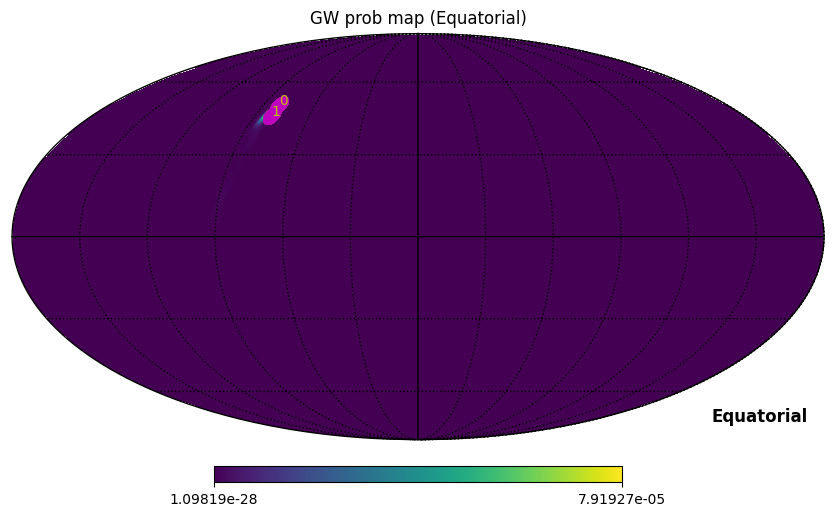

'dp_dV': no galaxies given
cannot access local variable 'galprob' where it is not associated with a value: no galaxies given for plot 2


In [16]:
from tilepy.tools.VisualizationTools import CompareTwoTilings, Pretty_Plot, PlotPointings_Pretty
print(name)


plotType = "gnomonic"


CompareTwoTilings(skymap, PointingsFile2, PointingsFile2)

skymap_HEALPix = dict_skymaps_HEALPix[name]


# PlotPointings_Pretty(skymap_HEALPix, name, PointingsFile1, outDir, obspar, catalog, dict_pointings[name], None, None)
Pretty_Plot(skymap_HEALPix, name, PointingsFile1, outDir, obspar, cat, dict_pointings[name], None, None)
# plotType = "mollweide"
# CompareTwoTilings(skymap, PointingsFile1, PointingsFile1, plotType)

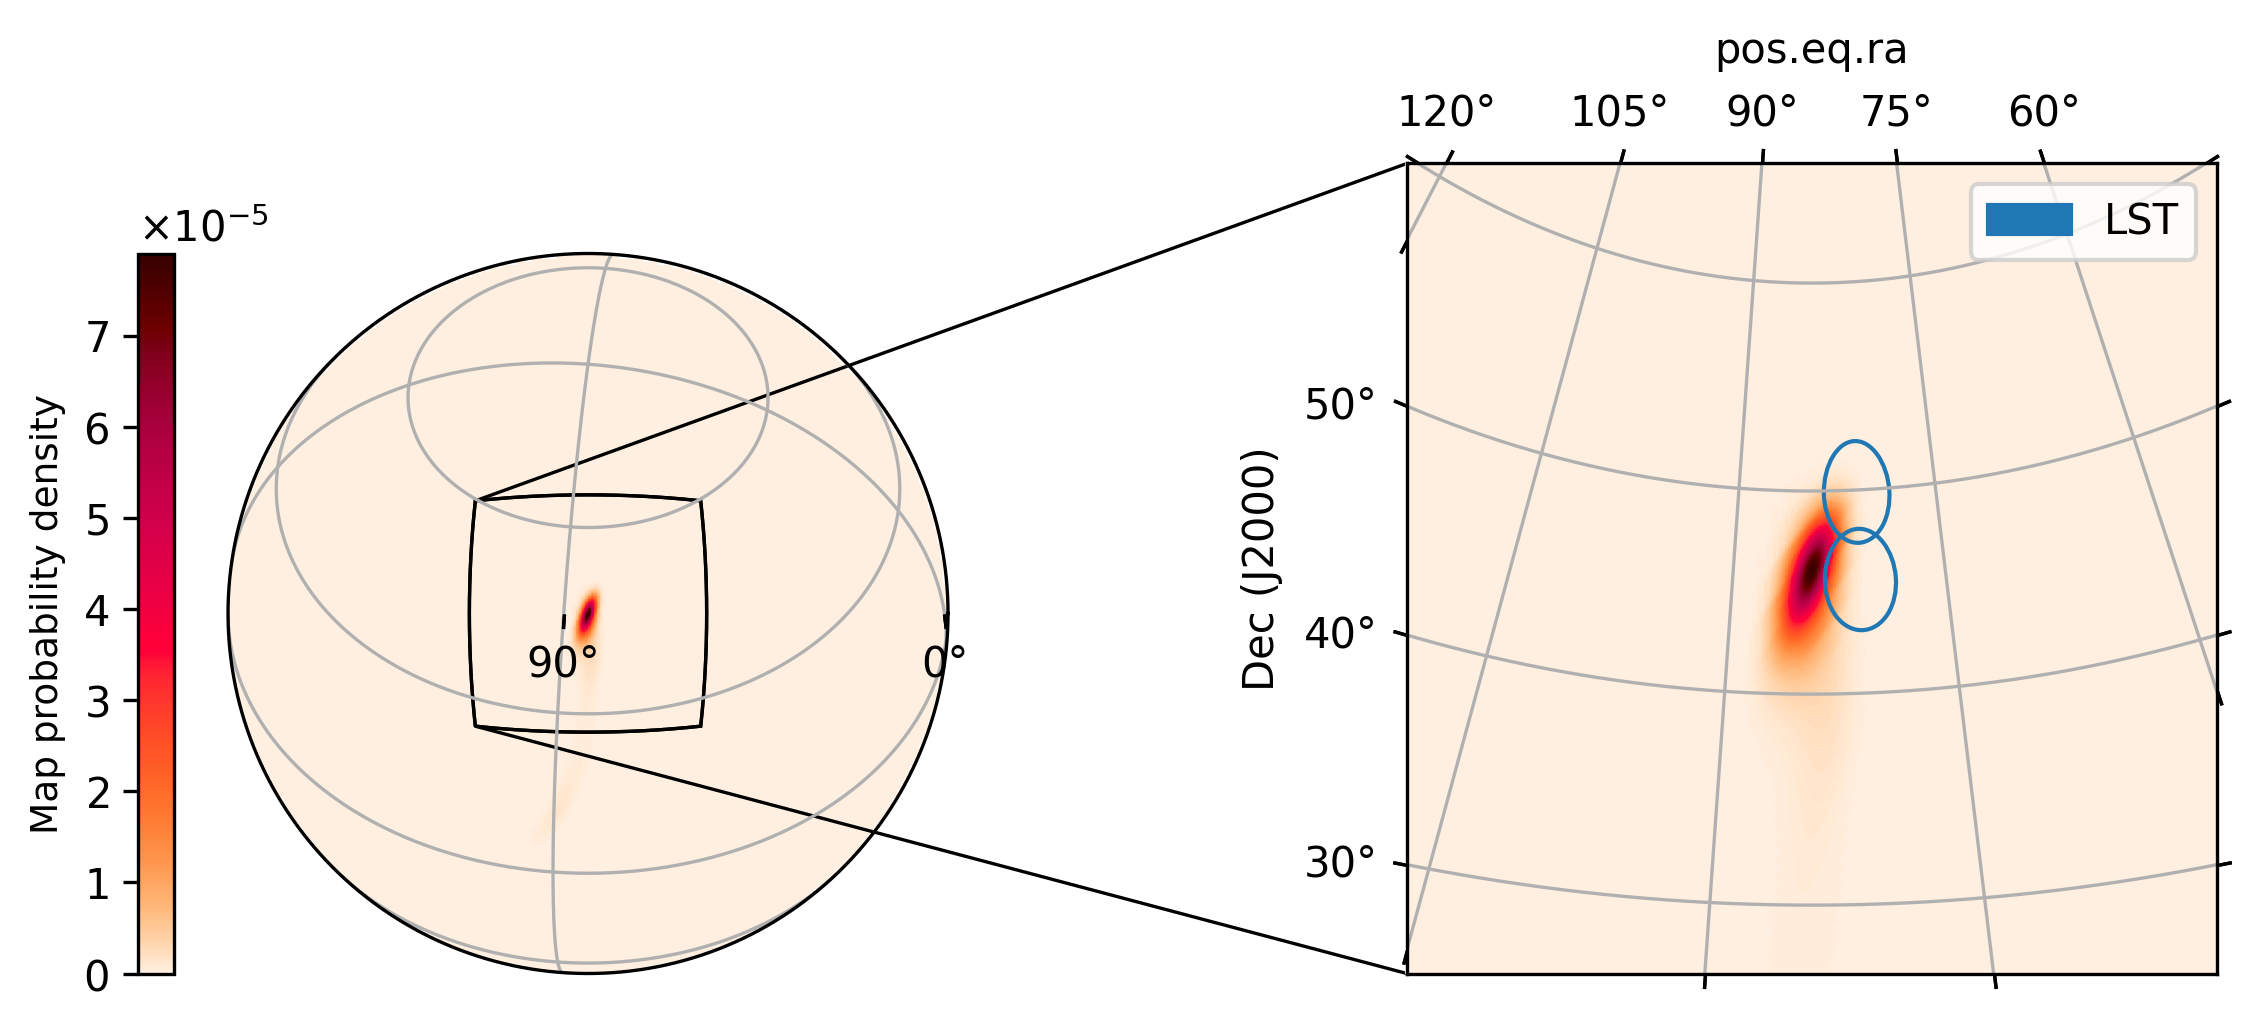

In [17]:
from IPython.display import Image, display

display(Image(f"{outDir}/Plot_PrettyMap_{name}.png"))